## Analysis Comment ver.
- 노트북 파일과 동일 경로에 data 폴더를 만들고 preproccess 파일들을 불러와서 실행할 것
- 총 정리본이라 셀 병합 최대한 해서 옮겨쓰기 편하게 만들어 놓은 것
- 중간 결과 값을 보려면 새 노트북에 파일 만들어서 셀 나눠서 실행하며 결과 비교할 것
- 전체 주석 처리 되어 있는 셀은 streamlit으로 구현이 가능한 지 테스트를 위한 셀로 실제 작동이 되지 않을 가능성이 있는 예시 셀임
- folium 관련 셀은 .html 파일로 노트북파일과 동일 경로에 생기니 실행 후, 확인해보거나 아래에 셀을 만들어 해당변수(m)를 실행해 볼 것(오래걸릴수있음)


In [108]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import MarkerCluster



In [ ]:
# pd.read_csv() : CSV 파일을 불러와서 데이터프레임으로 만드는 함수
# encoding="utf-8-sig" : 한글이 깨지지 않게 파일 인코딩 지정

df = pd.read_csv("data/danger_clean.csv", encoding="utf-8-sig")


In [110]:
print(df.head())
print(df.columns)

               발표시간  지역 시군구 재난종류 특보등급  \
0  2023-01-01 10:00  경북  군위   한파  주의보   
1  2023-01-01 10:00  경북  안동   한파  주의보   
2  2023-01-01 10:00  경북  영주   한파  주의보   
3  2023-01-01 10:00  경북  의성   한파  주의보   
4  2023-01-01 10:00  경북  청송   한파  주의보   

                                                해당지역  
0  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...  
1  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...  
2  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...  
3  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...  
4  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...  
Index(['발표시간', '지역', '시군구', '재난종류', '특보등급', '해당지역'], dtype='str')


### 지역별 예특보

#### 지역 종류별 히트맵

In [111]:
# -----------------------------------
# 1. 분석에 필요한 컬럼 값 정리
# -----------------------------------

# "지역", "재난종류" 둘 중 하나라도 값이 비어있는 행은 제거
# 이유: 히트맵은 지역과 재난종류가 둘 다 있어야 집계 가능함
df = df.dropna(subset=["지역", "재난종류"])

# "지역" 컬럼을 문자열(str) 형태로 바꾸고,
# 앞뒤 공백을 제거
# 예: " 울산 " -> "울산"
df["지역"] = df["지역"].astype(str).str.strip()

# "재난종류" 컬럼도 문자열로 바꾸고 앞뒤 공백 제거
df["재난종류"] = df["재난종류"].astype(str).str.strip()


# -----------------------------------
# 2. 지역별 + 재난종류별 발생 건수 세기
# -----------------------------------

# groupby(["지역", "재난종류"])
# -> 같은 지역 / 같은 재난종류끼리 묶음
#
# .size()
# -> 각 묶음의 개수(행 수)를 셈
#
# .reset_index(name="특보건수")
# -> 결과를 다시 표 형태로 만들고,
#    개수 컬럼 이름을 "특보건수"로 지정
heatmap_data = (
    df.groupby(["지역", "재난종류"])
    .size()
    .reset_index(name="특보건수")
)

# 여기까지 하면 대충 이런 표가 만들어짐
# 지역   재난종류   특보건수
# 울산   호우       12
# 울산   태풍        4
# 부산   호우        9


# -----------------------------------
# 3. 히트맵용 표 형태로 변환
# -----------------------------------

# pivot()은 세로형 데이터를 가로형 표로 바꾸는 기능
#
# index="지역"
# -> 행(세로축)에 지역이 들어감
#
# columns="재난종류"
# -> 열(가로축)에 재난종류가 들어감
#
# values="특보건수"
# -> 각 칸에 들어갈 값은 특보건수
#
# .fillna(0)
# -> 값이 없는 칸은 NaN 대신 0으로 채움
pivot_df = heatmap_data.pivot(
    index="지역",
    columns="재난종류",
    values="특보건수"
).fillna(0)

# 결과 예시
# 재난종류   호우   태풍   강풍
# 지역
# 울산       12     4      1
# 부산        9     2      3


# -----------------------------------
# 4. 지역별 총합 계산 후 많이 발생한 순서로 정렬
# -----------------------------------

# 각 지역 행의 가로 합계를 계산해서 "합계" 컬럼 추가
# axis=1 은 행 기준으로 더하라는 뜻
pivot_df["합계"] = pivot_df.sum(axis=1)

# "합계"가 큰 지역부터 위로 오도록 내림차순 정렬
# ascending=False -> 큰 값부터 정렬
#
# 그리고 정렬만 하고 나면 "합계" 컬럼은 히트맵에 필요 없으니 제거
pivot_df = pivot_df.sort_values("합계", ascending=False).drop(columns="합계")


# -----------------------------------
# 5. 히트맵 그리기
# -----------------------------------

# px.imshow()는 2차원 표 데이터를 색으로 표현하는 그래프
# 값이 클수록 더 진한 색으로 표시됨
fig = px.imshow(
    pivot_df,                       # 히트맵으로 그릴 표 데이터
    text_auto=True,                 # 각 칸 안에 숫자 자동 표시
    aspect="auto",                  # 가로세로 비율 자동 조정
    color_continuous_scale="Blues", # 파란색 계열 색상 사용
    title="지역별·재난종류별 예특보 발생 히트맵",  # 그래프 제목
    labels=dict(
        x="재난종류",               # x축 이름
        y="지역",                   # y축 이름
        color="특보건수"            # 색상바 이름
    )
)


# -----------------------------------
# 6. 그래프 전체 꾸미기
# -----------------------------------

fig.update_layout(
    width=1000,                     # 그래프 가로 길이
    height=650,                     # 그래프 세로 길이
    title_x=0.5,                    # 제목 가운데 정렬 (0.5 = 중앙)
    font=dict(size=14),             # 전체 글자 크기
    coloraxis_colorbar=dict(title="특보건수")  # 오른쪽 색상바 제목
)


# -----------------------------------
# 7. 칸 안 숫자 글자 크기 조정
# -----------------------------------

fig.update_traces(
    textfont=dict(size=12)          # 각 칸에 적히는 숫자 크기
)


# -----------------------------------
# 8. 그래프 출력
# -----------------------------------

# 지금까지 만든 히트맵을 화면에 보여줌
fig.show()

#### 지역별 발생 건수

In [112]:
# -----------------------------------
# 0. 원본 데이터 보존
# -----------------------------------

# df 원본을 그대로 두고, 시각화 전용 복사본을 만듦
# copy() : 데이터프레임을 복사해서 원본이 안 바뀌게 함
plot_df = df.copy()


# -----------------------------------
# 1. 시각화에 필요한 행만 남기기
# -----------------------------------

# "지역", "재난종류" 값이 둘 다 있는 행만 남김
# notna() : 비어있지 않은 값인지 확인
# 조건을 만족하는 행만 골라서 새로운 데이터프레임으로 만듦
plot_df = plot_df[
    plot_df["지역"].notna() &
    plot_df["재난종류"].notna()
].copy()

# "지역" 컬럼을 문자열로 바꾸고 앞뒤 공백 제거
# astype(str) : 문자열 형태로 변환
# str.strip() : 앞뒤 띄어쓰기 제거
plot_df["지역"] = plot_df["지역"].astype(str).str.strip()

# "재난종류" 컬럼도 문자열로 바꾸고 앞뒤 공백 제거
plot_df["재난종류"] = plot_df["재난종류"].astype(str).str.strip()


# -----------------------------------
# 2. 지역 + 재난종류별 특보 건수 세기
# -----------------------------------

# groupby() : 같은 값끼리 묶어주는 기능
# 여기서는 "지역"과 "재난종류"가 같은 것끼리 묶음
#
# size() : 묶인 각 그룹의 행 개수 세기
#
# reset_index(name="특보건수")
# : 결과를 다시 표 형태로 바꾸고, 개수 컬럼 이름을 "특보건수"로 지정
region_disaster_count = (
    plot_df.groupby(["지역", "재난종류"])
    .size()
    .reset_index(name="특보건수")
)


# -----------------------------------
# 3. 지역별 총 특보 건수 구하기
# -----------------------------------

# 지역별로만 묶어서 전체 특보 개수를 셈
# sort_values() : 값을 기준으로 정렬
# ascending=False : 큰 값부터 내림차순 정렬
region_total = (
    plot_df.groupby("지역")
    .size()
    .reset_index(name="총특보건수")
    .sort_values("총특보건수", ascending=False)
)


# -----------------------------------
# 4. 그래프에 사용할 지역 순서 정하기
# -----------------------------------

# 정렬된 region_total에서 "지역" 값만 리스트로 뽑음
# tolist() : 시리즈 값을 리스트로 변환
# 이렇게 하면 총합이 큰 지역부터 막대가 나오게 됨
region_order = region_total["지역"].tolist()


# -----------------------------------
# 5. 재난종류 순서 정하기
# -----------------------------------

# 재난종류별 발생 건수를 세고,
# 많이 나온 재난종류부터 정렬한 뒤,
# 그 이름만 리스트로 저장
disaster_order = (
    plot_df.groupby("재난종류")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)


# -----------------------------------
# 6. 막대 위에 총합 숫자를 표시할 위치 계산
# -----------------------------------

# 지역 총합 중 가장 큰 값 찾기
# max() : 최댓값 구하기
y_max = region_total["총특보건수"].max()

# 막대 위 숫자가 막대에 너무 붙지 않도록 약간 위로 띄울 값
# max(2, y_max * 0.03) :
# 최소 2만큼은 띄우고,
# 데이터가 크면 최대값의 3%만큼 띄움
offset = max(2, y_max * 0.03)

# 총합 숫자를 어디 높이에 표시할지 계산
region_total["표시위치"] = region_total["총특보건수"] + offset


# -----------------------------------
# 7. 누적 막대그래프 만들기
# -----------------------------------

# px.bar() : 막대그래프를 그리는 함수
fig = px.bar(
    region_disaster_count,   # 그래프에 사용할 데이터
    x="지역",                # x축: 지역
    y="특보건수",            # y축: 특보 건수
    color="재난종류",        # 색상 구분: 재난종류
    text="특보건수",         # 막대 안에 표시할 글자
    barmode="stack",         # 누적 막대 형태로 표시
    category_orders={        # 축과 범례 순서를 직접 지정
        "지역": region_order,
        "재난종류": disaster_order
    },
    title="지역별 재난종류 특보 발생 현황"   # 그래프 제목
)


# -----------------------------------
# 8. 막대 안 숫자 / 마우스 올렸을 때 정보 꾸미기
# -----------------------------------

# update_traces() : 그래프의 막대 모양, 글자, 마우스 설명 등을 수정
fig.update_traces(
    texttemplate="%{text}",   # text 값 그대로 표시
    textposition="inside",    # 숫자를 막대 안쪽에 표시
    textfont_size=12,         # 막대 안 숫자 크기
    insidetextanchor="middle",# 막대 안 가운데 정렬
    hovertemplate="<b>%{x}</b><br>재난종류: %{fullData.name}<br>특보건수: %{y}건<extra></extra>"
    # hovertemplate : 마우스를 올렸을 때 보이는 설명 형식 지정
)


# -----------------------------------
# 9. 막대 위에 지역별 총합 숫자 추가
# -----------------------------------

# add_scatter() : 점 그래프를 추가하는 함수
# 여기서는 점 대신 "글자(text)"만 추가해서 총합 숫자를 표시함
fig.add_scatter(
    x=region_total["지역"],          # x축 위치: 각 지역
    y=region_total["표시위치"],      # y축 위치: 막대보다 조금 위
    text=region_total["총특보건수"], # 표시할 글자: 총합 숫자
    mode="text",                    # 점이 아니라 글자만 표시
    textposition="top center",      # 글자 위치: 위쪽 가운데
    textfont=dict(size=14, color="black"),  # 글자 크기와 색
    showlegend=False,               # 범례에 이 항목은 표시하지 않음
    hoverinfo="skip"                # 마우스 올렸을 때 설명 생략
)


# -----------------------------------
# 10. 그래프 전체 레이아웃 꾸미기
# -----------------------------------

# update_layout() : 그래프 전체 크기, 제목, 축 이름, 범례 등을 설정
fig.update_layout(
    width=1100,                     # 그래프 가로 길이
    height=700,                     # 그래프 세로 길이
    title_x=0.5,                    # 제목 가운데 정렬
    xaxis_title="지역",             # x축 제목
    yaxis_title="특보 건수",        # y축 제목
    legend_title="재난종류",        # 범례 제목
    bargap=0.2,                     # 막대 사이 간격
    font=dict(size=14),             # 전체 글자 크기

    # y축 범위를 직접 지정
    # 막대 위 총합 숫자까지 잘 보이도록 위쪽 여유를 더 줌
    yaxis=dict(range=[0, region_total["표시위치"].max() + offset])
)


# -----------------------------------
# 11. 그래프 출력
# -----------------------------------

# show() : 완성된 그래프를 화면에 보여줌
fig.show()

### 월별 전체 특보 건수


In [113]:
# -----------------------------------
# 0. 원본 데이터 복사
# -----------------------------------

# df 원본을 그대로 두기 위해 복사본을 만듦
# copy() : 원본 손상 없이 따로 작업할 수 있게 복사
month_df = df.copy()


# -----------------------------------
# 1. 발표시간을 날짜형으로 변환
# -----------------------------------

# "발표시간" 컬럼을 datetime 형식으로 바꿈
# pd.to_datetime() : 날짜/시간 형태로 바꿔주는 함수
# errors="coerce" : 날짜로 변환이 안 되는 값은 NaT(결측값)으로 처리
month_df["발표시간"] = pd.to_datetime(month_df["발표시간"], errors="coerce")


# -----------------------------------
# 2. 필요한 데이터만 남기기
# -----------------------------------

# 발표시간이 비어있지 않고,
# 재난종류도 비어있지 않은 행만 남김
# notna() : 결측값이 아닌지 확인
month_df = month_df[
    month_df["발표시간"].notna() &
    month_df["재난종류"].notna()
].copy()


# -----------------------------------
# 3. 재난종류 문자열 정리
# -----------------------------------

# 재난종류를 문자열로 바꾸고 앞뒤 공백 제거
# astype(str) : 문자열로 변환
# str.strip() : 앞뒤 공백 제거
month_df["재난종류"] = month_df["재난종류"].astype(str).str.strip()


# -----------------------------------
# 4. 발표시간에서 월 정보 뽑기
# -----------------------------------

# datetime 형식의 발표시간에서 "월"만 추출
# .dt.month : 날짜형 데이터에서 월(month)만 가져옴
month_df["월"] = month_df["발표시간"].dt.month


# -----------------------------------
# 5. 가장 많이 나온 재난종류 5개 찾기
# -----------------------------------

# 재난종류별 개수를 세고,
# 많이 나온 순서대로 상위 5개만 고름
#
# value_counts() : 각 값이 몇 번 나왔는지 세기
# head(5) : 앞에서 5개만 가져오기
# index : 재난종류 이름만 가져오기
top_types = (
    month_df["재난종류"]
    .value_counts()
    .head(5)
    .index
)


# -----------------------------------
# 6. 상위 5개 재난종류만 남기기
# -----------------------------------

# isin(top_types) : top_types 안에 들어있는 값만 True
# 즉, 재난종류가 상위 5개인 데이터만 남김
plot_df = month_df[month_df["재난종류"].isin(top_types)].copy()


# -----------------------------------
# 7. 월별 + 재난종류별 특보 건수 계산
# -----------------------------------

# 월과 재난종류별로 묶어서 개수를 셈
# groupby() : 같은 값끼리 묶기
# size() : 각 그룹 개수 세기
# reset_index(name="특보건수") : 다시 표 형태로 만들고 컬럼명 지정
# sort_values(["월", "재난종류"]) : 월, 재난종류 순으로 정렬
monthly_type_count = (
    plot_df.groupby(["월", "재난종류"])
    .size()
    .reset_index(name="특보건수")
    .sort_values(["월", "재난종류"])
)


# -----------------------------------
# 8. 선 그래프 만들기
# -----------------------------------

# px.line() : 선 그래프를 그리는 함수
fig = px.line(
    monthly_type_count,           # 그래프에 사용할 데이터
    x="월",                       # x축: 월
    y="특보건수",                 # y축: 특보 건수
    color="재난종류",             # 선 색상 구분: 재난종류
    markers=True,                 # 각 지점에 점 표시
    title="주요 재난종류별 월별 특보 발생 추이"  # 그래프 제목
)


# -----------------------------------
# 9. 그래프 전체 꾸미기
# -----------------------------------

# update_layout() : 그래프 크기, 제목 위치, 축 제목 등을 설정
fig.update_layout(
    width=1100,                   # 그래프 가로 길이
    height=650,                   # 그래프 세로 길이
    title_x=0.5,                  # 제목 가운데 정렬
    xaxis_title="월",             # x축 제목
    yaxis_title="특보 건수",      # y축 제목
    legend_title="재난종류",      # 범례 제목

    # x축 눈금을 1월 ~ 12월로 고정해서 표시
    xaxis=dict(
        tickmode="array",                         # 눈금을 직접 지정
        tickvals=list(range(1, 13)),              # 눈금 위치: 1~12
        ticktext=[f"{i}월" for i in range(1, 13)] # 보이는 글자: 1월~12월
    )
)


# -----------------------------------
# 10. 그래프 출력
# -----------------------------------

# show() : 완성된 그래프를 화면에 표시
fig.show()

### 지역별 대피소 markercluster

In [114]:
import folium
# folium : 파이썬으로 지도를 만들 수 있게 해주는 라이브러리

from folium.plugins import MarkerCluster
# MarkerCluster : 지도에 마커가 많을 때 겹치는 것들을 묶어주는 기능


# -------------------------
# 1. 파일 불러오기
# -------------------------

# pd.read_csv() : CSV 파일을 불러와서 데이터프레임으로 만드는 함수
# encoding="utf-8-sig" : 한글이 깨지지 않게 파일 인코딩 지정
df = pd.read_csv("data/final_shelter_dataset.csv", encoding="utf-8-sig")


# -------------------------
# 2. 컬럼 확인
# -------------------------

# columns : 현재 데이터프레임의 컬럼(열) 이름들을 보여줌
# print() : 화면에 출력
print(df.columns)


# -------------------------
# 3. 필요한 컬럼 정리
# 컬럼명이 다르면 여기만 바꾸면 됨
# -------------------------

# rename() : 컬럼 이름을 바꾸는 함수
# 여기서는 "위도" -> "lat", "경도" -> "lon" 으로 바꿈
# 이유: 지도 함수에서 위도/경도를 더 짧고 보기 쉽게 쓰려고 함
df = df.rename(columns={
    "위도": "lat",
    "경도": "lon"
})


# 수용인원을 숫자형으로 변환
# pd.to_numeric() : 숫자로 바꿔주는 함수
# errors="coerce" : 숫자로 못 바꾸는 값은 NaN(결측값)으로 처리
df["수용인원"] = pd.to_numeric(df["수용인원"], errors="coerce")


# 위도(lat), 경도(lon) 중 하나라도 비어있는 행 제거
# dropna() : 결측값이 있는 행을 제거
# subset=["lat", "lon"] : lat, lon 컬럼만 기준으로 검사
df = df.dropna(subset=["lat", "lon"])


# -------------------------
# 4. 지도 중심 설정
# -------------------------

# mean() : 평균값 구하기
# 전체 대피소 좌표의 평균을 내서 지도 중심점을 잡음
center_lat = df["lat"].mean()
center_lon = df["lon"].mean()


# folium.Map() : 지도 객체를 만드는 함수
m = folium.Map(
    location=[center_lat, center_lon],  # 지도 처음 중심 위치
    zoom_start=8,                       # 처음 확대 정도
    tiles="OpenStreetMap"               # 지도 배경 스타일
)


# MarkerCluster() : 가까운 마커들을 묶어서 보여주는 기능
# add_to() : 만들어둔 지도 m에 추가
marker_cluster = MarkerCluster().add_to(m)


# -------------------------
# 5. 대피소 마커 추가
# 원 크기 = 수용인원 반영
# -------------------------

# iterrows() : 데이터프레임의 각 행을 한 줄씩 꺼내서 반복
# _ 는 인덱스이고 여기서는 안 쓰니 그냥 _ 로 둠
# row 는 각 행의 데이터
for _, row in df.iterrows():

    # get() : 해당 컬럼값을 가져오되,
    # 값이 없으면 뒤의 기본값을 사용
    shelter_name = row.get("대피소명", "정보없음")
    address = row.get("주소", "정보없음")
    capacity = row.get("수용인원", 0)

    # 원 크기 조절
    # 수용인원이 비어있으면 기본 반지름 4 사용
    # pd.isna() : 값이 결측값(NaN)인지 확인
    if pd.isna(capacity):
        radius = 4
        capacity_text = "정보없음"
    else:
        # max(4, ...) : 너무 작아지지 않게 최소 크기 4 보장
        # min(..., 20) : 너무 커지지 않게 최대 크기 20 제한
        # capacity / 300 : 수용인원에 따라 원 크기를 조금씩 키움
        radius = max(4, min(capacity / 300, 20))

        # f"{int(capacity):,}명"
        # int() : 정수로 바꾸기
        # :,  -> 천 단위 콤마 넣기
        # 예: 12000 -> 12,000
        capacity_text = f"{int(capacity):,}명"


    # 팝업에 띄울 HTML 형식 문자열
    # <br> : 줄바꿈
    # <b> : 굵은 글씨
    popup_text = f"""
    <b>대피소명:</b> {shelter_name}<br>
    <b>주소:</b> {address}<br>
    <b>수용인원:</b> {capacity_text}
    """


    # folium.CircleMarker() : 지도 위에 원형 마커를 찍는 함수
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],     # 마커 위치 (위도, 경도)
        radius=radius,                         # 원 크기
        popup=folium.Popup(popup_text, max_width=300),  # 클릭 시 뜨는 팝업
        tooltip=shelter_name,                 # 마우스 올리면 보이는 이름
        fill=True,                            # 원 내부 채우기
        fill_opacity=0.6                      # 원 내부 투명도
    ).add_to(marker_cluster)
    # add_to(marker_cluster) : 이 원형 마커를 클러스터에 추가


# -------------------------
# 6. 저장
# -------------------------

# save() : 만든 지도를 HTML 파일로 저장
# 나중에 브라우저에서 열어서 확인 가능
m.save("shelter_map.html")

Index(['대피소명', '주소', '대피소유형', '위도', '경도', '시도', '시군구', '지역', '수용인원'], dtype='str')


#### STREAMLIT VER.


In [115]:
# import streamlit as st
# # streamlit : 웹앱 형태로 화면을 만들 수 있게 해주는 라이브러리

# from streamlit_folium import st_folium
# # st_folium : folium 지도를 streamlit 화면에 띄워주는 기능


# # -------------------------
# # 1. 페이지 제목 만들기
# # -------------------------

# # st.title() : 페이지 맨 위에 큰 제목 표시
# st.title("대피소 위치 지도")


# # -------------------------
# # 2. CSV 파일 불러오기
# # -------------------------

# # pd.read_csv() : CSV 파일을 읽어서 표 형태 데이터로 불러옴
# # encoding="utf-8-sig" : 한글 깨짐 방지용 인코딩 설정
# df = pd.read_csv("data/final_shelter_dataset.csv", encoding="utf-8-sig")


# # -------------------------
# # 3. 위도/경도 컬럼 이름 바꾸기
# # -------------------------

# # rename() : 컬럼 이름을 바꾸는 함수
# # "위도", "경도"를 짧게 "lat", "lon"으로 바꿔서 이후 코드에서 쓰기 쉽게 만듦
# df = df.rename(columns={
#     "위도": "lat",
#     "경도": "lon"
# })


# # -------------------------
# # 4. 수용인원 숫자형 변환
# # -------------------------

# # pd.to_numeric() : 값을 숫자 형태로 바꾸는 함수
# # errors="coerce" : 숫자로 바꿀 수 없는 값은 NaN(결측값) 처리
# df["수용인원"] = pd.to_numeric(df["수용인원"], errors="coerce")


# # -------------------------
# # 5. 좌표 없는 행 제거
# # -------------------------

# # dropna() : 결측값이 있는 행 제거
# # subset=["lat", "lon"] : 위도, 경도 기준으로만 검사
# # 지도에는 좌표가 꼭 필요하므로 lat/lon 없는 데이터는 제거
# df = df.dropna(subset=["lat", "lon"])


# # -------------------------
# # 6. 지도 중심 좌표 계산
# # -------------------------

# # mean() : 평균값 구하기
# # 전체 대피소 위도/경도 평균으로 지도 중심을 설정
# center_lat = df["lat"].mean()
# center_lon = df["lon"].mean()


# # -------------------------
# # 7. 지도 객체 만들기
# # -------------------------

# # folium.Map() : 지도를 생성하는 함수
# m = folium.Map(
#     location=[center_lat, center_lon],  # 지도 처음 중심 위치
#     zoom_start=8,                       # 처음 확대 정도
#     tiles="OpenStreetMap"               # 배경 지도 스타일
# )


# # -------------------------
# # 8. 마커 클러스터 만들기
# # -------------------------

# # MarkerCluster() : 가까운 마커끼리 묶어서 보여주는 기능
# # add_to(m) : 방금 만든 지도 m에 추가
# marker_cluster = MarkerCluster().add_to(m)


# # -------------------------
# # 9. 각 대피소를 지도에 표시
# # -------------------------

# # iterrows() : 데이터프레임의 각 행을 하나씩 반복
# for _, row in df.iterrows():

#     # get() : 특정 컬럼값 가져오기
#     # 값이 없으면 뒤의 기본값 사용
#     shelter_name = row.get("대피소명", "정보없음")
#     address = row.get("주소", "정보없음")
#     capacity = row.get("수용인원", 0)

#     # 수용인원 값이 비어있는지 확인
#     # pd.isna() : NaN(결측값)인지 확인
#     if pd.isna(capacity):
#         radius = 4
#         capacity_text = "정보없음"
#     else:
#         # 원 크기 조절
#         # capacity / 300 : 수용인원에 비례해 원을 키움
#         # min(..., 20) : 너무 커지지 않게 최대 20 제한
#         # max(4, ...) : 너무 작아지지 않게 최소 4 보장
#         radius = max(4, min(capacity / 300, 20))

#         # int() : 정수로 변환
#         # :, : 천 단위 콤마 표시
#         capacity_text = f"{int(capacity):,}명"

#     # 마커 클릭 시 보일 팝업 내용
#     # <b> : 굵은 글씨
#     # <br> : 줄바꿈
#     popup_text = f"""
#     <b>대피소명:</b> {shelter_name}<br>
#     <b>주소:</b> {address}<br>
#     <b>수용인원:</b> {capacity_text}
#     """

#     # folium.CircleMarker() : 지도에 원형 마커 추가
#     folium.CircleMarker(
#         location=[row["lat"], row["lon"]],          # 마커 위치
#         radius=radius,                              # 원 크기
#         popup=folium.Popup(popup_text, max_width=300),  # 클릭 시 팝업창
#         tooltip=shelter_name,                       # 마우스 올리면 보이는 이름
#         fill=True,                                  # 원 내부 채우기
#         fill_opacity=0.6                            # 원 내부 투명도
#     ).add_to(marker_cluster)
#     # add_to(marker_cluster) : 이 마커를 클러스터에 추가


# # -------------------------
# # 10. streamlit 화면에 지도 띄우기
# # -------------------------

# # st_folium() : folium 지도를 streamlit 화면 안에 표시
# # width, height : 지도 표시 크기
# st_folium(m, width=1000, height=600)

### 대피소 위치 클러스터

In [116]:
import pandas as pd
# pandas : 표 형태 데이터(DataFrame)를 다루는 라이브러리

import folium
# folium : 파이썬으로 지도를 만들 수 있게 해주는 라이브러리


# -----------------------------------
# 1. 원본 보존 + 지도용 데이터 준비
# -----------------------------------

# pd.read_csv() : CSV 파일을 불러오는 함수
# encoding="utf-8-sig" : 한글 깨짐 방지용 인코딩 설정
df = pd.read_csv("data/final_shelter_dataset.csv", encoding="utf-8-sig")

# copy() : 원본 df를 그대로 두고 복사본을 만들어 작업
map_df = df.copy()

# columns : 컬럼 이름들
# str.strip() : 컬럼명 앞뒤 공백 제거
# 예: " 위도 " -> "위도"
map_df.columns = map_df.columns.str.strip()

# notna() : 값이 비어있지 않은지 확인
# 위도, 경도, 대피소유형이 모두 있는 행만 남김
# copy() : 필터링한 결과를 새 데이터프레임으로 복사
map_df = map_df[
    map_df["위도"].notna() &
    map_df["경도"].notna() &
    map_df["대피소유형"].notna()
].copy()

# pd.to_numeric() : 숫자 형태로 변환
# errors="coerce" : 숫자로 바꿀 수 없는 값은 NaN 처리
map_df["위도"] = pd.to_numeric(map_df["위도"], errors="coerce")
map_df["경도"] = pd.to_numeric(map_df["경도"], errors="coerce")

# astype(str) : 문자열로 변환
# str.strip() : 앞뒤 공백 제거
map_df["대피소유형"] = map_df["대피소유형"].astype(str).str.strip()

# dropna() : 결측값이 있는 행 제거
# 위도, 경도 중 하나라도 비어 있으면 지도에 표시할 수 없으므로 제거
map_df = map_df.dropna(subset=["위도", "경도"])


# -----------------------------------
# 2. 지도 중심
# -----------------------------------

# mean() : 평균값 구하기
# 전체 대피소 위치의 평균 위도/경도를 지도 중심으로 사용
center_lat = map_df["위도"].mean()
center_lon = map_df["경도"].mean()

# folium.Map() : 지도 객체 생성
m = folium.Map(
    location=[center_lat, center_lon],  # 지도 시작 중심 좌표
    zoom_start=8,                       # 시작 확대 정도
    tiles="CartoDB positron"            # 배경 지도 스타일
)


# -----------------------------------
# 3. 대피소 유형별 색상 지정
# -----------------------------------

# unique() : 중복 없는 값만 추출
# tolist() : 리스트로 변환
# sorted() : 오름차순 정렬
# 즉, 대피소유형 종류 목록을 정리해서 리스트로 만듦
type_list = sorted(map_df["대피소유형"].unique().tolist())

# 지도에 사용할 색상 목록
color_pool = [
    "#2563eb",  # blue
    "#dc2626",  # red
    "#16a34a",  # green
    "#f59e0b",  # amber
    "#7c3aed",  # violet
    "#0891b2",  # cyan
    "#db2777",  # pink
    "#4b5563",  # gray
    "#65a30d",  # lime
    "#ea580c",  # orange
]

# 딕셔너리 컴프리헨션
# enumerate() : 리스트를 돌면서 (번호, 값) 같이 꺼냄
# i % len(color_pool) : 색이 부족하면 다시 처음 색부터 반복 사용
# 결과: "대피소유형 : 색상코드" 형태의 딕셔너리 생성
type_color_map = {
    shelter_type: color_pool[i % len(color_pool)]
    for i, shelter_type in enumerate(type_list)
}


# -----------------------------------
# 4. 유형별 레이어 만들기
# 레이어 이름에 색깔 점 같이 표시
# -----------------------------------

# 레이어들을 저장할 딕셔너리
layer_dict = {}

# 각 대피소유형마다 따로 켜고 끌 수 있는 레이어를 만듦
for shelter_type in type_list:
    color = type_color_map[shelter_type]

    # 레이어 이름을 HTML로 꾸밈
    # 색깔 점 + 대피소유형 이름이 같이 보이게 설정
    layer_name = f"""
    <span style="display:inline-flex; align-items:center; gap:6px;">
        <span style="
            display:inline-block;
            width:10px;
            height:10px;
            border-radius:50%;
            background:{color};
            border:1px solid #666;
        "></span>
        <span>{shelter_type}</span>
    </span>
    """

    # folium.FeatureGroup() : 지도에서 하나의 레이어 그룹 생성
    # name=layer_name : 레이어 컨트롤에 표시될 이름
    # show=True : 처음부터 보이게 설정
    layer = folium.FeatureGroup(name=layer_name, show=True)

    # 만든 레이어를 딕셔너리에 저장
    layer_dict[shelter_type] = layer

    # add_child() : 지도 m에 레이어 추가
    m.add_child(layer)


# -----------------------------------
# 5. 마커 추가
# -----------------------------------

# iterrows() : 데이터프레임의 각 행을 하나씩 반복
for _, row in map_df.iterrows():

    # get() : 컬럼값 가져오기
    # 값이 없으면 뒤의 기본값 사용
    shelter_name = row.get("대피소명", "정보없음")
    shelter_type = row.get("대피소유형", "정보없음")
    address = row.get("주소", "정보없음")
    sido = row.get("시도", "")
    sigungu = row.get("시군구", "")

    # 현재 대피소유형에 해당하는 색상 가져오기
    color = type_color_map[shelter_type]

    # 팝업에 보여줄 HTML 내용
    # <div> : 내용 묶음
    # <b> : 굵은 글씨
    # <br> : 줄바꿈
    popup_html = f"""
    <div style="font-size:13px; line-height:1.6;">
        <b>대피소명</b> : {shelter_name}<br>
        <b>대피소유형</b> : {shelter_type}<br>
        <b>지역</b> : {sido} {sigungu}<br>
        <b>주소</b> : {address}
    </div>
    """

    # folium.CircleMarker() : 지도에 원형 마커 생성
    folium.CircleMarker(
        location=[row["위도"], row["경도"]],      # 마커 위치
        radius=5,                                # 원 크기
        color=color,                             # 원 테두리 색
        weight=1.2,                              # 테두리 두께
        fill=True,                               # 원 내부 채우기
        fill_color=color,                        # 내부 색상
        fill_opacity=0.85,                       # 내부 투명도
        popup=folium.Popup(popup_html, max_width=320),  # 클릭 시 팝업
        tooltip=f"{shelter_name} ({shelter_type})"      # 마우스 올렸을 때 표시
    ).add_to(layer_dict[shelter_type])
    # add_to() : 해당 대피소유형 레이어에 마커 추가


# -----------------------------------
# 6. 레이어 컨트롤 추가
# -----------------------------------

# folium.LayerControl() : 레이어를 켜고 끌 수 있는 컨트롤 추가
# collapsed=False : 접히지 않은 상태로 펼쳐서 표시
folium.LayerControl(collapsed=False).add_to(m)


# -----------------------------------
# 7. 저장 및 출력
# -----------------------------------

# save() : 완성된 지도를 HTML 파일로 저장
m.save("shelter_type_layer_map1.html")

#### STREAMLIT VER.


In [117]:
# import pandas as pd
# # pandas : 표 형태 데이터(DataFrame)를 다루는 라이브러리

# import streamlit as st
# # streamlit : 파이썬 코드로 웹앱 화면을 만드는 라이브러리

# import folium
# # folium : 파이썬으로 지도를 만드는 라이브러리

# from streamlit_folium import st_folium
# # st_folium : folium 지도를 streamlit 화면에 띄워주는 기능


# # -----------------------------------
# # 0. 스트림릿 페이지 기본 설정
# # -----------------------------------

# # st.set_page_config() : 웹페이지의 제목, 레이아웃 등을 설정
# st.set_page_config(page_title="대피소 유형별 지도", layout="wide")

# # st.title() : 페이지 맨 위 큰 제목 표시
# st.title("대피소 유형별 분포 지도")


# # -----------------------------------
# # 1. 데이터 불러오기
# # -----------------------------------

# # @st.cache_data
# # : 같은 데이터를 다시 불러올 때 속도를 빠르게 하기 위한 캐시 기능
# #   한 번 읽은 결과를 저장해두고 재사용함
# @st.cache_data
# def load_data():
#     # pd.read_csv() : CSV 파일 불러오기
#     df = pd.read_csv("data/final_shelter_dataset.csv", encoding="utf-8-sig")

#     # 컬럼명 앞뒤 공백 제거
#     # columns : 컬럼 이름 목록
#     # str.strip() : 문자열 앞뒤 공백 제거
#     df.columns = df.columns.str.strip()

#     # 위도, 경도, 대피소유형 값이 있는 행만 남김
#     # notna() : 값이 비어있지 않은지 확인
#     map_df = df[
#         df["위도"].notna() &
#         df["경도"].notna() &
#         df["대피소유형"].notna()
#     ].copy()

#     # 위도, 경도를 숫자형으로 변환
#     # pd.to_numeric() : 숫자로 바꾸기
#     # errors="coerce" : 숫자로 못 바꾸는 값은 NaN 처리
#     map_df["위도"] = pd.to_numeric(map_df["위도"], errors="coerce")
#     map_df["경도"] = pd.to_numeric(map_df["경도"], errors="coerce")

#     # 대피소유형을 문자열로 바꾸고 공백 제거
#     # astype(str) : 문자열로 변환
#     # str.strip() : 앞뒤 공백 제거
#     map_df["대피소유형"] = map_df["대피소유형"].astype(str).str.strip()

#     # 숫자로 변환한 뒤에도 위도, 경도가 비어 있으면 제거
#     # dropna() : 결측값 제거
#     map_df = map_df.dropna(subset=["위도", "경도"])

#     # 정리된 데이터 반환
#     return map_df

# # load_data() 함수 실행해서 지도용 데이터 저장
# map_df = load_data()


# # -----------------------------------
# # 2. 대피소 유형 목록 + 색상 지정
# # -----------------------------------

# # unique() : 중복 없는 값만 추출
# # tolist() : 리스트로 변환
# # sorted() : 정렬
# # 즉, 대피소유형 목록을 정리해서 리스트로 만듦
# type_list = sorted(map_df["대피소유형"].unique().tolist())

# # 각 유형에 배정할 색상 목록
# color_pool = [
#     "#2563eb",  # blue
#     "#dc2626",  # red
#     "#16a34a",  # green
#     "#f59e0b",  # amber
#     "#7c3aed",  # violet
#     "#0891b2",  # cyan
#     "#db2777",  # pink
#     "#4b5563",  # gray
#     "#65a30d",  # lime
#     "#ea580c",  # orange
# ]

# # 딕셔너리 컴프리헨션
# # enumerate() : (번호, 값) 형태로 꺼내기
# # i % len(color_pool) : 유형 수가 색상 수보다 많아도 색을 반복해서 사용
# # 결과: {"유형명": "색상코드"} 형태
# type_color_map = {
#     shelter_type: color_pool[i % len(color_pool)]
#     for i, shelter_type in enumerate(type_list)
# }


# # -----------------------------------
# # 3. 사이드바 필터
# # -----------------------------------

# # st.sidebar.header() : 사이드바 안에 제목 표시
# st.sidebar.header("지도 필터")

# # st.sidebar.multiselect()
# # : 여러 개를 선택할 수 있는 선택창
# selected_types = st.sidebar.multiselect(
#     "대피소 유형 선택",   # 선택창 이름
#     options=type_list,   # 선택 가능한 목록
#     default=type_list    # 처음에는 전체 선택 상태
# )

# # 색상 안내 제목
# st.sidebar.markdown("### 유형별 색상")

# # 각 유형마다 색상 점과 이름을 사이드바에 표시
# for shelter_type in type_list:
#     color = type_color_map[shelter_type]

#     # st.sidebar.markdown() : 사이드바에 마크다운/HTML 표시
#     # unsafe_allow_html=True : HTML 태그를 실제로 적용해서 보여줌
#     st.sidebar.markdown(
#         f"""
#         <div style="display:flex; align-items:center; margin-bottom:6px;">
#             <span style="
#                 display:inline-block;
#                 width:12px;
#                 height:12px;
#                 border-radius:50%;
#                 background:{color};
#                 margin-right:8px;
#                 border:1px solid #666;
#             "></span>
#             <span>{shelter_type}</span>
#         </div>
#         """,
#         unsafe_allow_html=True
#     )


# # -----------------------------------
# # 4. 필터 적용
# # -----------------------------------

# # isin(selected_types) : 선택된 유형에 포함되는 행만 남김
# filtered_df = map_df[map_df["대피소유형"].isin(selected_types)].copy()

# # st.write() : 화면에 글이나 값 출력
# # len() : 데이터 개수 세기
# st.write(f"선택된 대피소 수: **{len(filtered_df):,}개**")

# # empty : 데이터프레임이 비어있는지 확인
# if filtered_df.empty:
#     # st.warning() : 노란 경고 메시지 표시
#     st.warning("선택된 조건에 해당하는 대피소가 없사옵니다.")
# else:
#     # -----------------------------------
#     # 5. 지도 생성
#     # -----------------------------------

#     # mean() : 평균값 구하기
#     # 선택된 대피소들의 평균 위도/경도를 지도 중심으로 사용
#     center_lat = filtered_df["위도"].mean()
#     center_lon = filtered_df["경도"].mean()

#     # folium.Map() : 지도 객체 생성
#     m = folium.Map(
#         location=[center_lat, center_lon],  # 지도 시작 중심
#         zoom_start=8,                       # 시작 확대 정도
#         tiles="CartoDB positron"            # 지도 배경 스타일
#     )

#     # iterrows() : 데이터프레임의 각 행을 하나씩 반복
#     for _, row in filtered_df.iterrows():
#         # get() : 값 가져오기, 없으면 기본값 사용
#         shelter_name = row.get("대피소명", "정보없음")
#         shelter_type = row.get("대피소유형", "정보없음")
#         address = row.get("주소", "정보없음")
#         sido = row.get("시도", "")
#         sigungu = row.get("시군구", "")

#         # 현재 대피소 유형에 맞는 색상 가져오기
#         color = type_color_map[shelter_type]

#         # 마커 클릭 시 보일 팝업 내용
#         popup_html = f"""
#         <div style="font-size:13px; line-height:1.6;">
#             <b>대피소명</b> : {shelter_name}<br>
#             <b>대피소유형</b> : {shelter_type}<br>
#             <b>지역</b> : {sido} {sigungu}<br>
#             <b>주소</b> : {address}
#         </div>
#         """

#         # folium.CircleMarker() : 지도에 원형 마커 추가
#         folium.CircleMarker(
#             location=[row["위도"], row["경도"]],      # 마커 위치
#             radius=5,                                # 원 크기
#             color="white",                           # 원 테두리 색
#             weight=1,                                # 테두리 두께
#             fill=True,                               # 원 내부 채우기
#             fill_color=color,                        # 내부 색상
#             fill_opacity=0.9,                        # 내부 투명도
#             popup=folium.Popup(popup_html, max_width=320),  # 클릭 팝업
#             tooltip=f"{shelter_name} ({shelter_type})"      # 마우스 올렸을 때 표시
#         ).add_to(m)
#         # add_to(m) : 만든 마커를 지도에 추가

#     # -----------------------------------
#     # 6. 스트림릿에 지도 출력
#     # -----------------------------------

#     # st_folium() : folium 지도를 streamlit 화면에 표시
#     st_folium(m, width=1100, height=700)

### 추천 대피소간 평균 거리가 얼마인가

In [118]:
import pandas as pd
import numpy as np
import re

# -----------------------------------
# 1. 파일 불러오기
# -----------------------------------
danger = pd.read_csv("data/danger_clean.csv", encoding="utf-8-sig")
shelter = pd.read_csv("data/final_shelter_dataset.csv", encoding="utf-8-sig")

danger.columns = danger.columns.str.strip()
shelter.columns = shelter.columns.str.strip()

# -----------------------------------
# 2. 지역명 / 시군구명 정리 함수
# -----------------------------------
def normalize_region(x):
    x = str(x).strip()
    return (
        x.replace("광역시", "")
         .replace("특별시", "")
         .replace("특별자치시", "")
         .replace("특별자치도", "")
         .replace("도", "")
    )

def normalize_sigungu(x):
    x = str(x).strip()
    x = re.sub(r"\s+", "", x)

    for suffix in ["특별자치시", "특별자치도", "시", "군", "구"]:
        x = x.replace(suffix, "")

    return x

# -----------------------------------
# 3. 기본 전처리
# -----------------------------------
danger["지역_norm"] = danger["지역"].apply(normalize_region)
danger["시군구_norm"] = danger["시군구"].apply(normalize_sigungu)

shelter["위도"] = pd.to_numeric(shelter["위도"], errors="coerce")
shelter["경도"] = pd.to_numeric(shelter["경도"], errors="coerce")
shelter = shelter.dropna(subset=["위도", "경도"]).copy()

shelter["지역_norm"] = shelter["시도"].apply(normalize_region)
shelter["시군구_norm"] = shelter["시군구"].apply(normalize_sigungu)

# -----------------------------------
# 4. danger 쪽 기준 좌표 만들기
#    (시군구 단위 중심점 -> 없으면 지역 전체 중심점)
# -----------------------------------
centroid_sigungu = (
    shelter.groupby(["지역_norm", "시군구_norm"], as_index=False)[["위도", "경도"]]
    .mean()
    .rename(columns={"위도": "기준위도", "경도": "기준경도"})
)

centroid_region = (
    shelter.groupby("지역_norm", as_index=False)[["위도", "경도"]]
    .mean()
    .rename(columns={"위도": "지역기준위도", "경도": "지역기준경도"})
)

danger_base = (
    danger.merge(centroid_sigungu, on=["지역_norm", "시군구_norm"], how="left")
          .merge(centroid_region, on="지역_norm", how="left")
)

danger_base["기준위도"] = danger_base["기준위도"].fillna(danger_base["지역기준위도"])
danger_base["기준경도"] = danger_base["기준경도"].fillna(danger_base["지역기준경도"])

# -----------------------------------
# 5. 재난종류 -> 대피소유형 연결
# -----------------------------------
def map_target_shelter(disaster):
    d = str(disaster).strip()

    if d == "지진":
        return "지진옥외대피장소"
    elif d in ["지진해일", "해일", "쓰나미", "폭풍해일"]:
        return "지진해일대피장소"
    else:
        return "쉼터"

danger_base["연결대피유형"] = danger_base["재난종류"].apply(map_target_shelter)

# -----------------------------------
# 6. 후보 대피소 미리 분리
# -----------------------------------
candidate_sets = {
    "지진옥외대피장소": shelter[shelter["대피소유형"].str.contains("지진옥외대피장소", na=False)].reset_index(drop=True),
    "지진해일대피장소": shelter[shelter["대피소유형"].str.contains("지진해일대피장소", na=False)].reset_index(drop=True),
    "쉼터": shelter[shelter["대피소유형"].str.contains("쉼터", na=False)].reset_index(drop=True),
}

# -----------------------------------
# 7. 거리 계산 함수 (Haversine)
# -----------------------------------
def haversine_vector(lat1, lon1, lats2, lons2):
    R = 6371.0  # 지구 반지름(km)

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lats2 = np.radians(lats2)
    lons2 = np.radians(lons2)

    dlat = lats2 - lat1
    dlon = lons2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lats2) * np.sin(dlon / 2.0) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

# -----------------------------------
# 8. 각 행마다 가까운 대피소 3개 + 평균거리 구하기
# -----------------------------------
records = []

for _, row in danger_base.iterrows():
    candidates = candidate_sets[row["연결대피유형"]]

    dists = haversine_vector(
        row["기준위도"],
        row["기준경도"],
        candidates["위도"].to_numpy(),
        candidates["경도"].to_numpy()
    )

    top_idx = np.argsort(dists)[:3]
    top3 = candidates.iloc[top_idx].copy()
    top3["거리_km"] = dists[top_idx]
    top3 = top3.sort_values("거리_km").reset_index(drop=True)

    rec = {
        "평균거리_km": round(top3["거리_km"].mean(), 3)
    }

    for i in range(3):
        rec[f"{i+1}순위_대피소명"] = top3.loc[i, "대피소명"]
        rec[f"{i+1}순위_주소"] = top3.loc[i, "주소"]
        rec[f"{i+1}순위_대피소유형"] = top3.loc[i, "대피소유형"]
        rec[f"{i+1}순위_거리_km"] = round(float(top3.loc[i, "거리_km"]), 3)

    records.append(rec)

nearest_df = pd.concat([danger_base.reset_index(drop=True), pd.DataFrame(records)], axis=1)

# -----------------------------------
# 9. 최종 컬럼 정리
# -----------------------------------
final_df = nearest_df[
    [
        "발표시간",
        "지역",
        "시군구",
        "재난종류",
        "특보등급",
        "해당지역",
        "연결대피유형",
        "기준위도",
        "기준경도",
        "1순위_대피소명",
        "1순위_주소",
        "1순위_대피소유형",
        "1순위_거리_km",
        "2순위_대피소명",
        "2순위_주소",
        "2순위_대피소유형",
        "2순위_거리_km",
        "3순위_대피소명",
        "3순위_주소",
        "3순위_대피소유형",
        "3순위_거리_km",
        "평균거리_km"
    ]
].copy()

# 확인
print(final_df.head())

# 저장
final_df.to_csv("data/disaster_nearest_shelters.csv", index=False, encoding="utf-8-sig")
print("저장 완료: data/disaster_nearest_shelters.csv")

               발표시간  지역 시군구 재난종류 특보등급  \
0  2023-01-01 10:00  경북  군위   한파  주의보   
1  2023-01-01 10:00  경북  안동   한파  주의보   
2  2023-01-01 10:00  경북  영주   한파  주의보   
3  2023-01-01 10:00  경북  의성   한파  주의보   
4  2023-01-01 10:00  경북  청송   한파  주의보   

                                                해당지역 연결대피유형       기준위도  \
0  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...     쉼터  36.245174   
1  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...     쉼터  36.580787   
2  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...     쉼터  36.833252   
3  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...     쉼터  36.362034   
4  (1) 한파주의보 발표 : 경상북도(군위. 안동. 영주. 의성. 청송. 영양평지. ...     쉼터  36.395519   

         기준경도  1순위_대피소명  ... 1순위_거리_km  2순위_대피소명  \
0  128.783745   금천2리경로당  ...     1.079   빙계1리경로당   
1  128.739168  성도아파트경로당  ...     0.389    청머리경로당   
2  128.602008  현대아파트경로당  ...     0.832  화성리버빌경로당   
3  128.581514   괴산2리경로당  ...     0.395    윈도옥경로당   
4  129.033395   노래2리경로당  ...     2.272   금곡2리경로당

In [119]:
# -----------------------------------
# 1. 파일 불러오기
# -----------------------------------
df = pd.read_csv("data/disaster_nearest_shelters.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# 숫자형 변환
num_cols = ["1순위_거리_km", "2순위_거리_km", "3순위_거리_km", "평균거리_km"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------------
# 2. 재난종류별 평균거리 분석
# -----------------------------------
disaster_avg = (
    df.groupby("재난종류", as_index=False)
      .agg(
          재난건수=("재난종류", "count"),
          평균거리_km=("평균거리_km", "mean"),
          평균_1순위거리_km=("1순위_거리_km", "mean"),
          평균_2순위거리_km=("2순위_거리_km", "mean"),
          평균_3순위거리_km=("3순위_거리_km", "mean")
      )
)

# 보기 좋게 반올림
disaster_avg = disaster_avg.round(3)

# 평균거리 기준 정렬
disaster_avg = disaster_avg.sort_values("평균거리_km", ascending=False).reset_index(drop=True)

print(disaster_avg)

# 저장
disaster_avg.to_csv("data/disaster_type_distance_summary.csv", index=False, encoding="utf-8-sig")
print("저장 완료: data/disaster_type_distance_summary.csv")

   재난종류  재난건수  평균거리_km  평균_1순위거리_km  평균_2순위거리_km  평균_3순위거리_km
0  폭풍해일    49   34.495       34.251       34.531       34.703
1    태풍    20    0.929        0.614        0.979        1.194
2    대설   238    0.920        0.602        0.956        1.203
3    한파   310    0.904        0.644        0.946        1.122
4    건조   525    0.773        0.546        0.803        0.969
5    호우  1110    0.759        0.533        0.787        0.958
6    폭염   569    0.754        0.529        0.788        0.943
7    강풍   724    0.692        0.499        0.702        0.874
저장 완료: data/disaster_type_distance_summary.csv


In [123]:
disaster_avg

,재난종류,재난건수,평균거리_km,평균_1순위거리_km,평균_2순위거리_km,평균_3순위거리_km
0,폭풍해일,49,34.495,34.251,34.531,34.703
1,태풍,20,0.929,0.614,0.979,1.194
2,대설,238,0.920,0.602,0.956,1.203
3,한파,310,0.904,0.644,0.946,1.122
4,건조,525,0.773,0.546,0.803,0.969
5,호우,1110,0.759,0.533,0.787,0.958
6,폭염,569,0.754,0.529,0.788,0.943
7,강풍,724,0.692,0.499,0.702,0.874


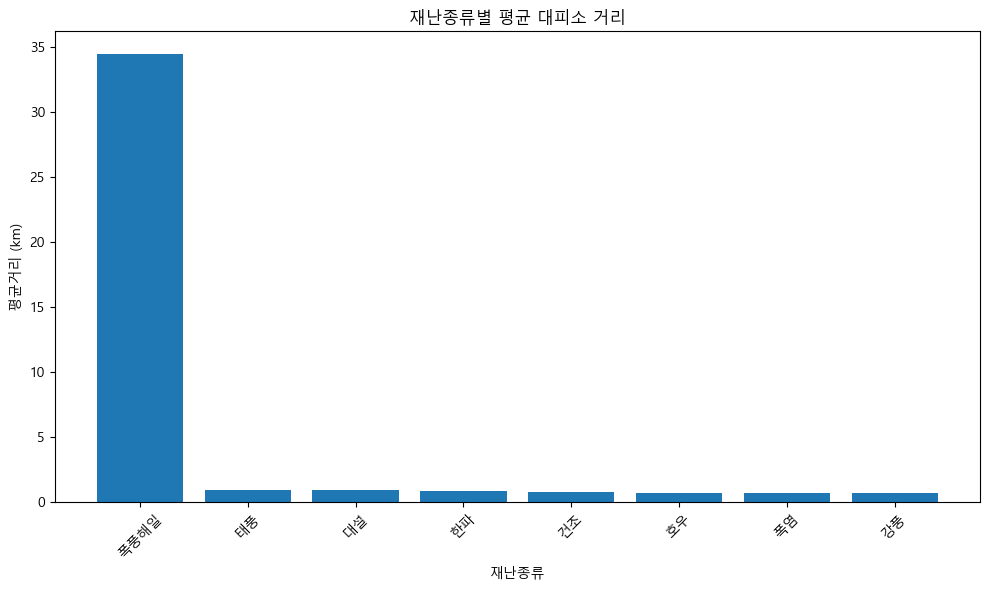

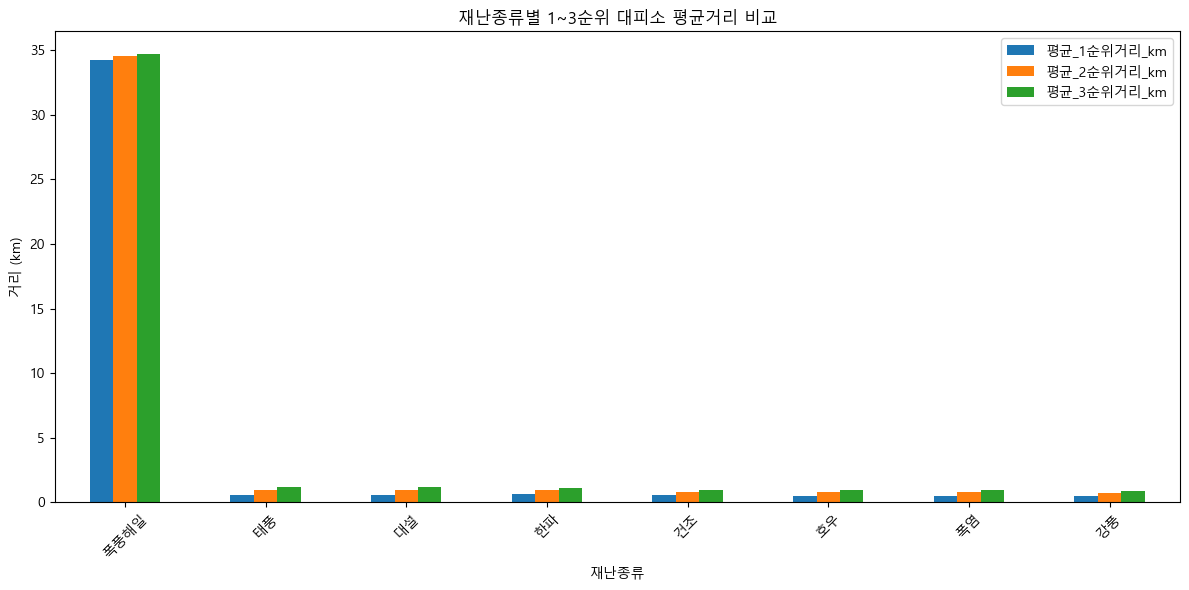

In [122]:
import matplotlib as mpl
import matplotlib.pyplot as plt
df = pd.read_csv("data/disaster_type_distance_summary.csv", encoding="utf-8-sig")


# 한글 깨짐 방지 (윈도우 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------------
# 1. 재난종류별 평균거리 막대그래프
# -----------------------------------
plt.figure(figsize=(10, 6))
plt.bar(df["재난종류"], df["평균거리_km"])
plt.title("재난종류별 평균 대피소 거리")
plt.xlabel("재난종류")
plt.ylabel("평균거리 (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------
# 2. 재난종류별 1~3순위 평균거리 비교
# -----------------------------------
plot_df = df.set_index("재난종류")[["평균_1순위거리_km", "평균_2순위거리_km", "평균_3순위거리_km"]]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("재난종류별 1~3순위 대피소 평균거리 비교")
plt.xlabel("재난종류")
plt.ylabel("거리 (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()